<a href="https://colab.research.google.com/github/guilhermemoraes-lasalle/ColecoesEassociacoes/blob/main/Exercicio_Matplotlib_BI_Vendas_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático — Visualização de Dados com Matplotlib

## Business Intelligence — Análise Visual de Vendas

Este notebook trabalha recursos do **Matplotlib** do nível básico ao intermediário/avançado:

- gráficos de linha;
- gráficos de barras;
- histogramas;
- API orientada a objetos;
- `subplots`;
- eixos duplos com `twinx()`;
- anotações com `annotate()`;
- tabelas dinâmicas;
- heatmaps com `imshow()`;
- exportação de gráficos em alta resolução.


## 1. Configuração do Ambiente e Dados Iniciais


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(
    start='2024-01-01',
    periods=n_registros,
    freq='D'
)

categorias = [
    'Eletronicos',
    'Livros',
    'Roupas',
    'Automotivo'
]

estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(
        categorias,
        size=n_registros
    ),
    'estado': np.random.choice(
        estados,
        size=n_registros
    ),
    'valor': np.random.uniform(
        50,
        4500,
        size=n_registros
    ).round(2),
    'quantidade': np.random.randint(
        1,
        15,
        size=n_registros
    ),
}

df = pd.DataFrame(dados)

df['valor_venda'] = (
    df['valor'] *
    np.random.uniform(
        0.9,
        1.1,
        size=n_registros
    )
).round(2)

print("Dataset criado com sucesso!")
display(df.head())

print("\nDimensões:", df.shape)


Dataset criado com sucesso!


,data,categoria,estado,valor,quantidade,valor_venda
0,2024-01-01,Roupas,BA,2228.06,13,2182.83
1,2024-01-02,Automotivo,RJ,4436.14,12,4538.93
2,2024-01-03,Eletronicos,BA,1127.15,10,1157.60
3,2024-01-04,Roupas,RJ,3041.00,7,2764.45
4,2024-01-05,Roupas,SP,3439.21,9,3352.96



Dimensões: (120, 6)


## Preparação das Métricas Mensais


In [2]:
# Garantindo que a coluna data esteja no formato datetime
df['data'] = pd.to_datetime(df['data'])

# Criando uma versão indexada pela data
df_temporal = df.set_index('data')

# Faturamento mensal
faturamento_mensal = (
    df_temporal['valor_venda']
    .resample('ME')
    .sum()
)

# Quantidade total mensal
quantidade_mensal = (
    df_temporal['quantidade']
    .resample('ME')
    .sum()
)

# Quantidade média de itens por venda
quantidade_media_mensal = (
    df_temporal['quantidade']
    .resample('ME')
    .mean()
)

print("Faturamento mensal:")
display(faturamento_mensal)

print("\nQuantidade total mensal:")
display(quantidade_mensal)


Faturamento mensal:


,valor_venda
data,
2024-01-31,67175.25
2024-02-29,68789.63
2024-03-31,74797.44
2024-04-30,78041.03



Quantidade total mensal:


,quantidade
data,
2024-01-31,246
2024-02-29,229
2024-03-31,229
2024-04-30,246


# Parte 1 — Gráficos Essenciais e Personalização


## 2. Gráfico de Linha — Faturamento Mensal


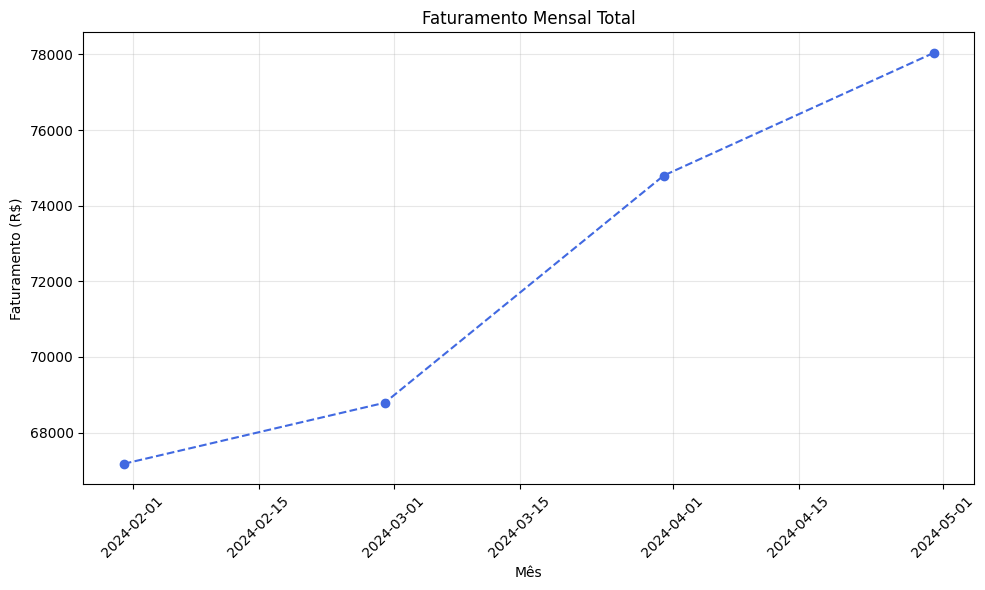

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

plt.title('Faturamento Mensal Total')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Gráfico de Barras — Total de Vendas por Categoria


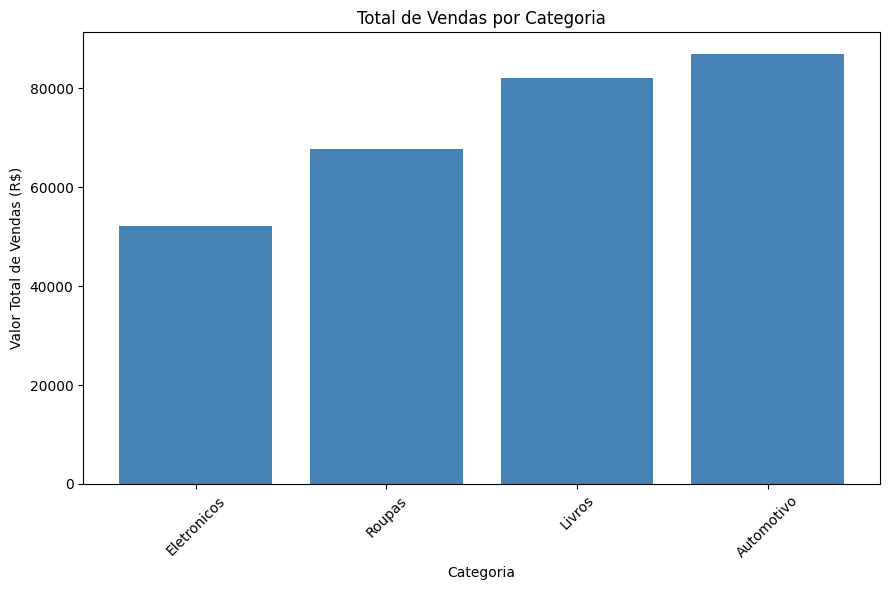

In [4]:
vendas_categoria = (
    df.groupby('categoria')['valor_venda']
    .sum()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='steelblue'
)

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor Total de Vendas (R$)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 4. Histograma — Distribuição dos Valores das Vendas


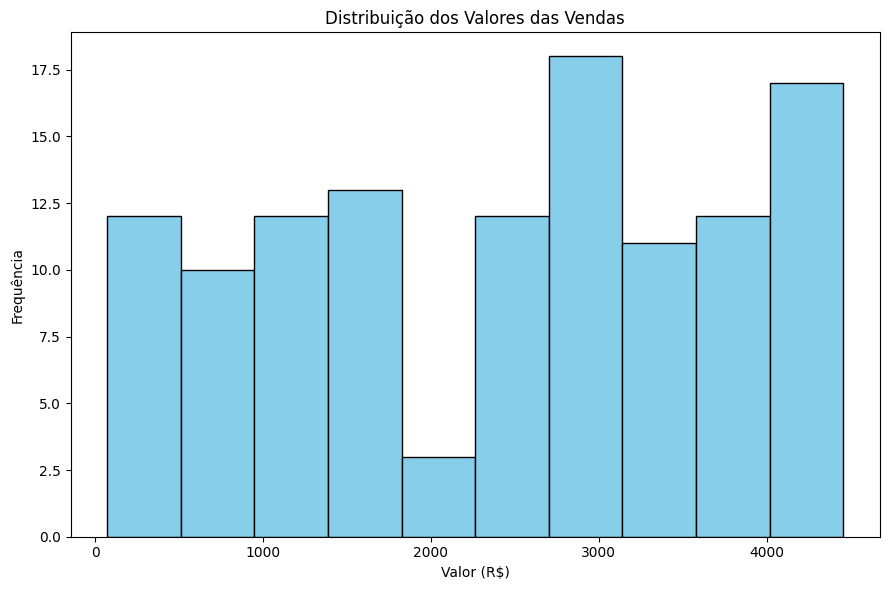

In [5]:
plt.figure(figsize=(9, 6))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


# Parte 2 — API Orientada a Objetos e Eixos Múltiplos


## 5. Subplots 2 × 1 com Eixo X Compartilhado


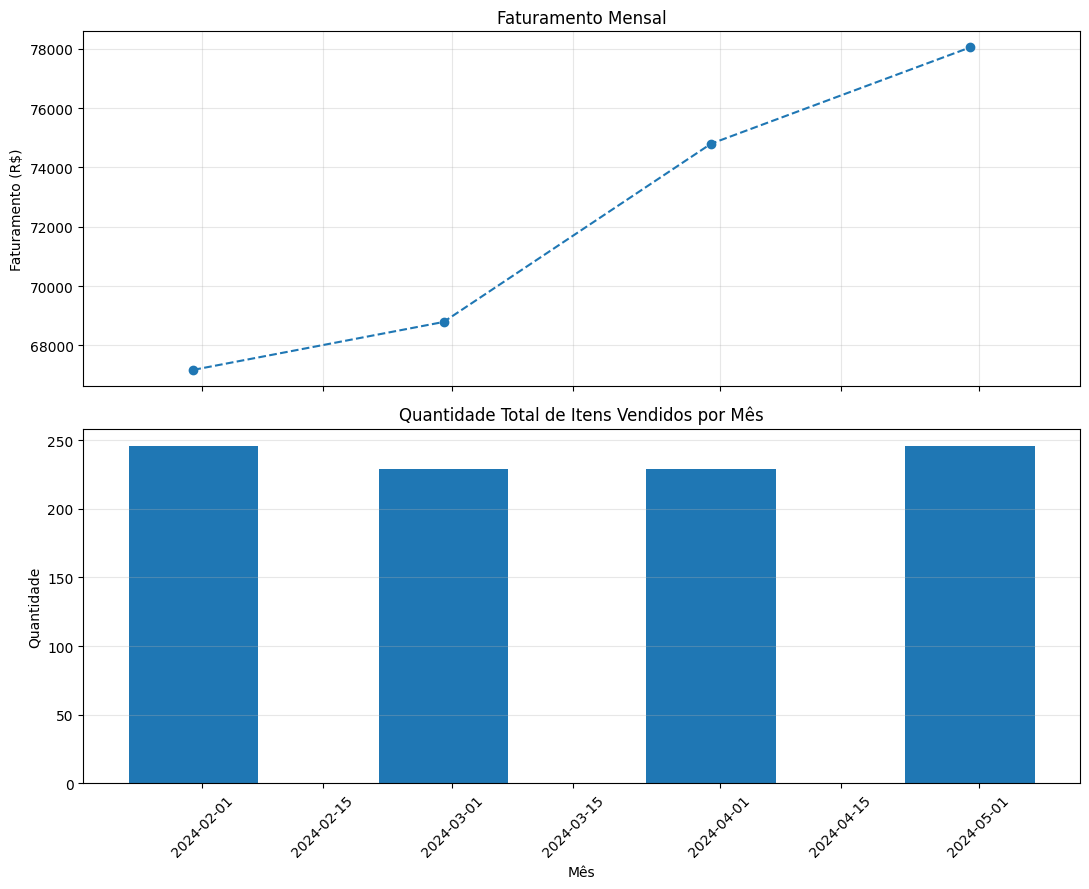

In [6]:
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True
)

# Gráfico superior
ax1.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--'
)

ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, alpha=0.3)

# Gráfico inferior
ax2.bar(
    quantidade_mensal.index,
    quantidade_mensal.values,
    width=15
)

ax2.set_title('Quantidade Total de Itens Vendidos por Mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade')
ax2.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)

fig.tight_layout()
plt.show()


## 6. Gráfico com Dois Eixos Y — `twinx()`


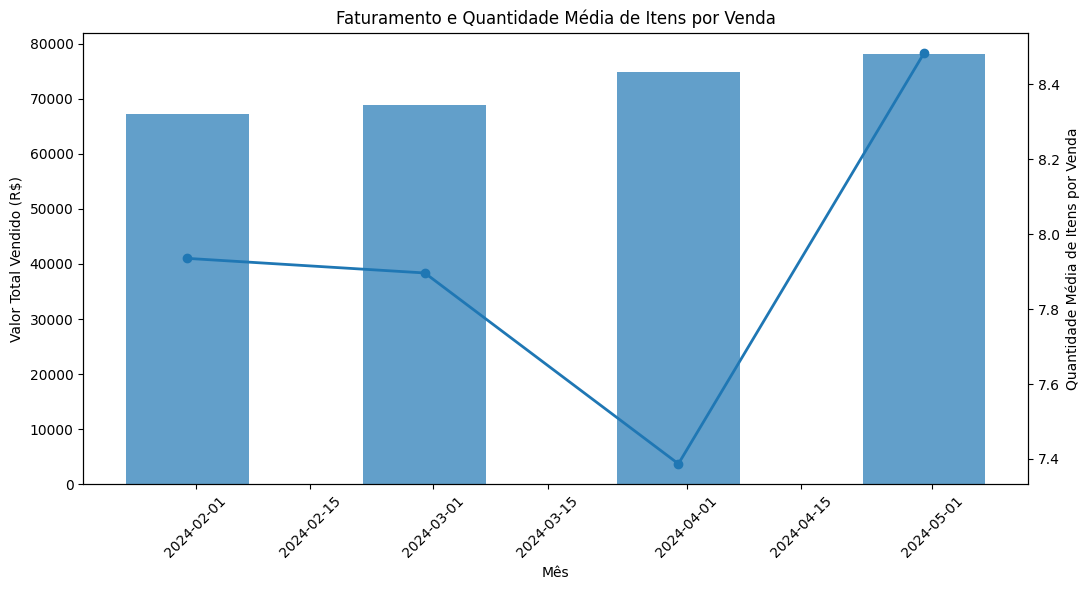

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# Eixo primário
ax.bar(
    faturamento_mensal.index,
    faturamento_mensal.values,
    width=15,
    alpha=0.7,
    label='Faturamento'
)

ax.set_xlabel('Mês')
ax.set_ylabel('Valor Total Vendido (R$)')
ax.set_title(
    'Faturamento e Quantidade Média de Itens por Venda'
)

# Criando eixo secundário
ax_secundario = ax.twinx()

ax_secundario.plot(
    quantidade_media_mensal.index,
    quantidade_media_mensal.values,
    marker='o',
    linewidth=2,
    label='Quantidade média'
)

ax_secundario.set_ylabel(
    'Quantidade Média de Itens por Venda'
)

ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()


## 7. Anotação do Mês de Maior Faturamento


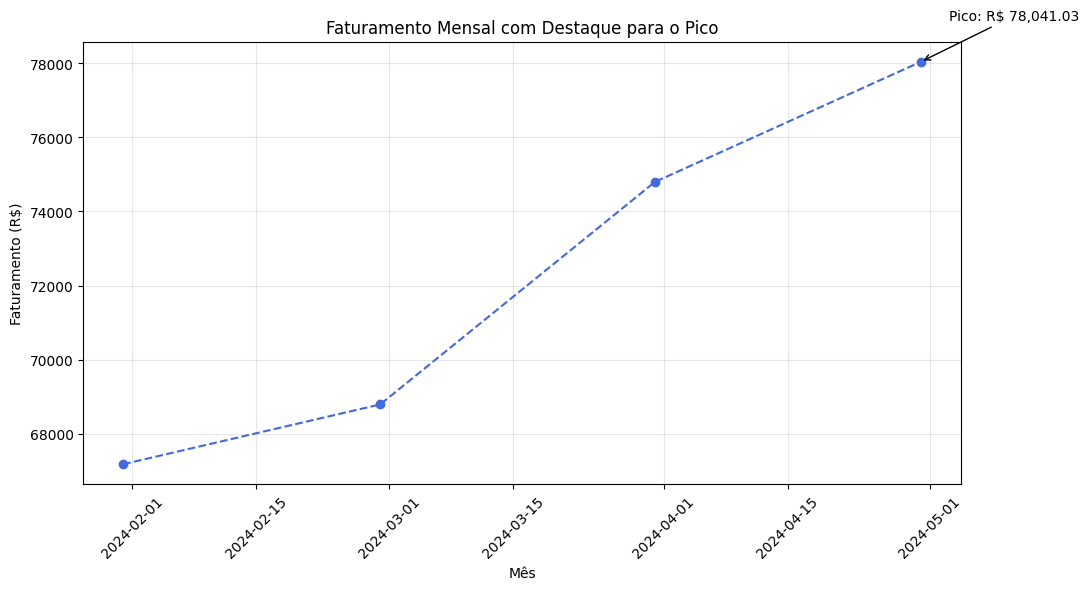

Mês de maior faturamento: 04/2024
Valor: R$ 78,041.03


In [8]:
# Identificando o mês com maior faturamento
mes_pico = faturamento_mensal.idxmax()
valor_pico = faturamento_mensal.max()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

ax.set_title(
    'Faturamento Mensal com Destaque para o Pico'
)
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True, alpha=0.3)

# Anotação com seta
ax.annotate(
    f'Pico: R$ {valor_pico:,.2f}',
    xy=(mes_pico, valor_pico),
    xytext=(20, 30),
    textcoords='offset points',
    arrowprops={
        'arrowstyle': '->',
        'connectionstyle': 'arc3'
    },
    fontsize=10
)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(
    'Mês de maior faturamento:',
    mes_pico.strftime('%m/%Y')
)

print(
    f'Valor: R$ {valor_pico:,.2f}'
)


# Parte 3 — Matriz de Intensidade / Heatmap


## 8. Construção da Tabela Dinâmica


In [9]:
tabela_heatmap = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum',
    fill_value=0
)

print('Tabela dinâmica — Vendas por Categoria e Estado:')
display(tabela_heatmap)


Tabela dinâmica — Vendas por Categoria e Estado:


estado,BA,MG,RJ,RS,SP
categoria,,,,,
Automotivo,6992.96,16333.39,26783.38,10122.88,26727.57
Eletronicos,14211.94,13453.06,1154.47,13966.62,9372.80
Livros,4318.03,25667.11,9659.57,19302.59,23104.72
Roupas,26968.88,9876.74,11120.83,4809.04,14856.77


## 9. Heatmap com `imshow()`


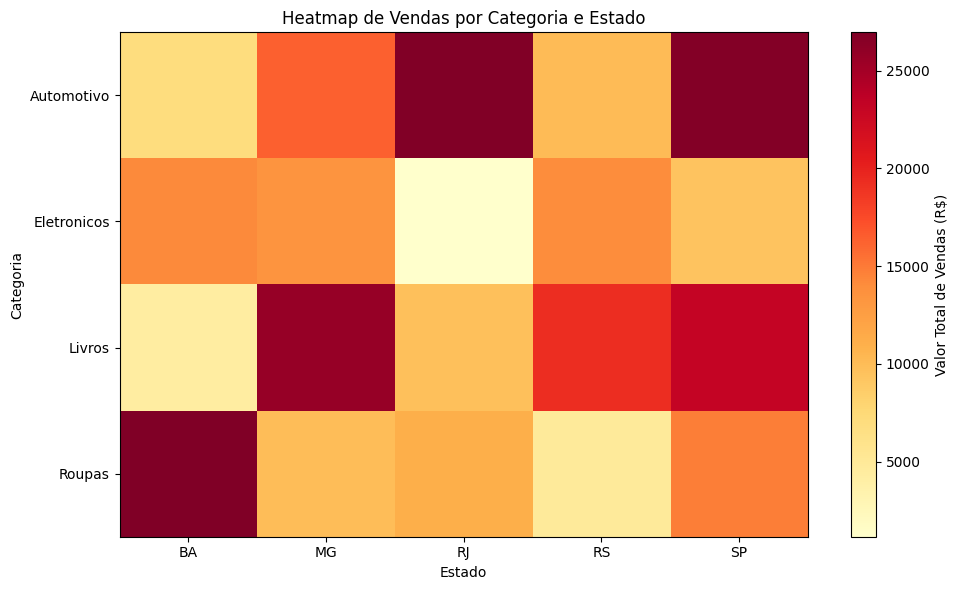

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

imagem = ax.imshow(
    tabela_heatmap.values,
    aspect='auto',
    cmap='YlOrRd'
)

# Barra de cores
barra_cores = fig.colorbar(
    imagem,
    ax=ax
)

barra_cores.set_label(
    'Valor Total de Vendas (R$)'
)

# Rótulos dos eixos
ax.set_xticks(
    np.arange(len(tabela_heatmap.columns))
)

ax.set_xticklabels(
    tabela_heatmap.columns
)

ax.set_yticks(
    np.arange(len(tabela_heatmap.index))
)

ax.set_yticklabels(
    tabela_heatmap.index
)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')
ax.set_title(
    'Heatmap de Vendas por Categoria e Estado'
)

plt.tight_layout()
plt.show()


## 10. Salvar Heatmap em PNG com 300 DPI


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

imagem = ax.imshow(
    tabela_heatmap.values,
    aspect='auto',
    cmap='YlOrRd'
)

barra_cores = fig.colorbar(
    imagem,
    ax=ax
)

barra_cores.set_label(
    'Valor Total de Vendas (R$)'
)

ax.set_xticks(
    np.arange(len(tabela_heatmap.columns))
)

ax.set_xticklabels(
    tabela_heatmap.columns
)

ax.set_yticks(
    np.arange(len(tabela_heatmap.index))
)

ax.set_yticklabels(
    tabela_heatmap.index
)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')

ax.set_title(
    'Heatmap de Vendas por Categoria e Estado'
)

# Salvando antes de exibir
plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "Arquivo 'heatmap_vendas.png' salvo com sucesso!"
)


## 11. Download do Heatmap no Google Colab


In [ ]:
# Executar esta célula no Google Colab para baixar a imagem
from google.colab import files

files.download('heatmap_vendas.png')


# Conclusão

Neste exercício foram aplicados recursos básicos, intermediários e avançados do Matplotlib:

- gráfico de linha personalizado;
- gráfico de barras;
- histograma;
- API orientada a objetos;
- múltiplos subplots;
- eixos Y duplos com `twinx()`;
- identificação e anotação do pico de faturamento;
- tabela dinâmica com Pandas;
- heatmap utilizando `imshow()`;
- barra de cores e rótulos nominais;
- exportação da visualização em PNG com resolução de **300 DPI**.

O notebook pode ser executado sequencialmente no Google Colab usando **Ambiente de execução → Executar tudo**.
